# ML-Augmented PEC Analysis — CuO/Carbon/SiO2 CO2-to-Methanol

**Authors:** Marco *et al.*  
**Last updated:** April 2025

| Symbol | Meaning |
|--------|---------|
| MEASURED | our experimental data |
| LITERATURE | published cited source |
| COMPUTED | derived via standard physics |

**Confirmed configuration:**

| Parameter | Value |
|-----------|-------|
| Substrate | Fused SiO2, 2x1 cm |
| Illuminated area | 1.0 cm2 (1x1 cm half) |
| Reference electrode | Ag/AgCl (sat. KCl) |
| Electrolyte | 0.5 M KOH, pH 13.7 |
| Light source | UV torch, 395 nm |
| RHE shift | E_RHE = E(Ag/AgCl) + 1.008 V |


## 0. Setup

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy import integrate
from scipy.constants import h, c, k, e as e_charge
from scipy.interpolate import interp1d
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
import warnings; warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'font.family': 'serif', 'font.size': 9, 'axes.labelsize': 10,
    'axes.linewidth': 0.9, 'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'legend.frameon': True, 'legend.framealpha': 0.92,
    'savefig.dpi': 300, 'pdf.fonttype': 42,
})

C_CUO='#C0392B'; C_AG2O='#2980B9'; C_AGO='#27AE60'; C_WO3='#8E44AD'
COLS = {'CuO': C_CUO, 'Ag2O': C_AG2O, 'AgO': C_AGO, 'WO3': C_WO3}
hc_eV_nm = 1239.8
print('Setup complete.')

Setup complete.


---

## 1. Experimental Data (MEASURED)
All values confirmed from this study. Do not modify without re-measurement.

In [2]:
# ── MEASURED: Electrochemical configuration ─────────────────────────────
ec = {
    'RE': 'Ag/AgCl (sat. KCl)',
    'E_RE_vs_NHE': 0.197,
    'electrolyte': '0.5 M KOH',
    'pH': 13.7,
    'lam_torch_nm': 395,
    'A_geo_cm2': 1.0,
}
RHE_shift = ec['E_RE_vs_NHE'] + 0.0592 * ec['pH']
ec['RHE_shift'] = RHE_shift
print(f'RHE shift = {RHE_shift:.3f} V  COMPUTED')

# ── Band gaps ────────────────────────────────────────────────────────────
# CuO: MEASURED (DRS/Tauc, this study)
# Ag2O, AgO, WO3: LITERATURE (cited below)
Eg = {
    'CuO':  {'indirect': 17.548/7.312,
              'direct':   0.31063/0.1274,
              'source': 'MEASURED: DRS/Tauc this study'},
    'Ag2O': {'indirect': 1.30, 'direct': 1.30,
              'source': 'LITERATURE: Cao et al. Inorg. Chem. 2011'},
    'AgO':  {'indirect': 1.70, 'direct': 1.70,
              'source': 'LITERATURE: Waterhouse et al. J. Phys. Chem. 2001'},
    'WO3':  {'indirect': 2.62, 'direct': 2.62,
              'source': 'LITERATURE: Mi et al. Chem. Commun. 2012'},
}
print(f'Eg(CuO) indirect = {Eg["CuO"]["indirect"]:.3f} eV  MEASURED')
print(f'Eg(CuO) direct   = {Eg["CuO"]["direct"]:.3f} eV  MEASURED')
for mat in ['Ag2O','AgO','WO3']:
    print(f'Eg({mat}) = {Eg[mat]["indirect"]:.2f} eV  {Eg[mat]["source"]}')

# ── MEASURED: Raman ──────────────────────────────────────────────────────
raman = {
    'D_cm1': 1333, 'G_cm1': 1566, '2D_cm1': 2649, 'DpD_cm1': 2906,
    'ID_IG': 1.30, 'ID_IG_unc': 0.05,
    'CuO_Ag': 290, 'CuO_Bg1': 345, 'CuO_Bg2': 630,
    'WO3_peaks': [270, 325, 715, 800],
    'WO3_note': 'Monoclinic WO3 (P21/n)',
}
print(f'Raman D/G = {raman["ID_IG"]:.2f} +/- {raman["ID_IG_unc"]}  MEASURED')

# ── MEASURED: PL ─────────────────────────────────────────────────────────
pl = {'ex_nm': 270, 'em1_nm': 370, 'em2_nm': 445}
hc_eV_nm = 1239.8
pl['stokes1_eV'] = round(hc_eV_nm/pl['ex_nm'] - hc_eV_nm/pl['em1_nm'], 3)
pl['stokes2_eV'] = round(hc_eV_nm/pl['ex_nm'] - hc_eV_nm/pl['em2_nm'], 3)
print(f'PL: ex={pl["ex_nm"]}nm  em={pl["em1_nm"]}nm, {pl["em2_nm"]}nm  MEASURED')

# ── MEASURED: LSV/Tafel ───────────────────────────────────────────────────
tafel = {
    'b_light_mV':  -92,
    'b_dark_mV':  -275,
    'I_light_mA':  350.0,
    'I_dark_mA':    26.0,
    'onset_AgAgCl': -1.10,
}
tafel['onset_RHE'] = tafel['onset_AgAgCl'] + RHE_shift
tafel['V12_RHE']   = -1.20 + RHE_shift
tafel['enh']       = tafel['I_light_mA'] / tafel['I_dark_mA']
print(f'Onset: {tafel["onset_AgAgCl"]:.2f} V vs AgAgCl -> {tafel["onset_RHE"]:.3f} V vs RHE')
print(f'Enhancement: {tafel["enh"]:.1f}x  MEASURED')

# ── MEASURED: BEP corrections ─────────────────────────────────────────────
# DFT/PBE-D3 bilayer calculations, this group
bep = {'CuO': 0.515, 'Ag2O': 0.602, 'AgO': 0.402}
# WO3 BEP not computed — excluded from CHE analysis

# ── MEASURED: Full PEC sample table ──────────────────────────────────────
samples = {
    'I':   {'stack': 'SiO2/C-glass(30min)/Ag2O(30s)', 'dark': 2.0,   'light': 7.0},
    'II':  {'stack': 'SiO2/C-glass(30min)/CuO(30s)',  'dark': 26.0,  'light': 350.0},
    'III': {'stack': 'SiO2/C-glass(105s)/Ag2O(30s)',  'dark': 0.07,  'light': None},
    'IV':  {'stack': 'SiO2/C-glass(105s)/CuO(30s)',   'dark': 0.265, 'light': 0.300},
    'V':   {'stack': 'SiO2/graphite(105s)/Ag2O(30s)', 'dark': 0.54,  'light': 0.60},
    'VI':  {'stack': 'SiO2/graphite(105s)/CuO(30s)',  'dark': 4.6,   'light': 18.0},
    'WO3': {'stack': 'SiO2/C(8min)/WO3(20min)',       'dark': None,  'light': 0.4},
}
print('\nSample table (-1.2 V vs Ag/AgCl, 0.5M KOH, 395nm):')
for s, v in samples.items():
    enh = f"{v['light']/v['dark']:.1f}x" if v['light'] and v['dark'] else '-'
    print(f'  {s}: dark={v["dark"]} mA  light={v["light"]} mA  enh={enh}')


RHE shift = 1.008 V  COMPUTED
Eg(CuO) indirect = 2.400 eV  MEASURED
Eg(CuO) direct   = 2.438 eV  MEASURED
Eg(Ag2O) = 1.30 eV  LITERATURE: Cao et al. Inorg. Chem. 2011
Eg(AgO) = 1.70 eV  LITERATURE: Waterhouse et al. J. Phys. Chem. 2001
Eg(WO3) = 2.62 eV  LITERATURE: Mi et al. Chem. Commun. 2012
Raman D/G = 1.30 +/- 0.05  MEASURED
PL: ex=270nm  em=370nm, 445nm  MEASURED
Onset: -1.10 V vs AgAgCl -> -0.092 V vs RHE
Enhancement: 13.5x  MEASURED

Sample table (-1.2 V vs Ag/AgCl, 0.5M KOH, 395nm):
  I: dark=2.0 mA  light=7.0 mA  enh=3.5x
  II: dark=26.0 mA  light=350.0 mA  enh=13.5x
  III: dark=0.07 mA  light=None mA  enh=-
  IV: dark=0.265 mA  light=0.3 mA  enh=1.1x
  V: dark=0.54 mA  light=0.6 mA  enh=1.1x
  VI: dark=4.6 mA  light=18.0 mA  enh=3.9x
  WO3: dark=None mA  light=0.4 mA  enh=-


---

## 2. Butler-Ginley Band Alignment  COMPUTED

Formula: E_CBM = chi_geo - Ee - Eg/2 (vs NHE). Eg(CuO) MEASURED; others LITERATURE pending own DRS/Tauc.

> Warning: Butler-Ginley is approximate (+/-0.3 V). Use Mott-Schottky or UPS for quantitative positions.

In [3]:
# Butler-Ginley Band Alignment (Butler & Ginley 1978)
chi_M = {'H':7.18,'O':7.54,'Cu':4.48,'Ag':4.44,'W':4.40}
Ee = 4.5  # eV

def chi_geo(formula):
    vals = [chi_M[el]**n for el,n in formula.items()]
    return float(np.prod(vals))**(1/sum(formula.values()))

formulas = {'CuO':{'Cu':1,'O':1},'Ag2O':{'Ag':2,'O':1},'AgO':{'Ag':1,'O':1},'WO3':{'W':1,'O':3}}
# CuO: MEASURED; Ag2O: Cao 2011 (1.30 eV); AgO: Waterhouse 2001 (1.70 eV); WO3: Mi 2012 (2.62 eV)
Eg_BG = {'CuO': Eg['CuO']['indirect'], 'Ag2O':1.30, 'AgO':1.70, 'WO3':2.62}

bg = {}
print(f'{"Mat":<6} {"chi":>8} {"Eg":>6} {"CBM/NHE":>10} {"VBM/NHE":>10} {"CBM/RHE":>10}  Src')
print('-'*60)
for mat, formula in formulas.items():
    eg = Eg_BG[mat]; ch = chi_geo(formula)
    cbm = ch - Ee - eg/2; vbm = cbm + eg
    cbm_rhe = cbm - 0.0592*ec['pH']
    bg[mat] = dict(chi=ch, Eg=eg, CBM=cbm, VBM=vbm, CBM_RHE=cbm_rhe)
    src = 'MEAS' if mat=='CuO' else 'LIT'
    print(f'{mat:<6} {ch:>8.3f} {eg:>6.2f} {cbm:>10.3f} {vbm:>10.3f} {cbm_rhe:>10.3f}  {src}')
print('-'*60)
print('CO2/CH3OH: -0.38 V vs RHE (NIST)')
print(f'Operating: {tafel["V12_RHE"]:.3f} to {tafel["onset_RHE"]:.3f} V vs RHE -> above CO2 threshold')

Mat         chi     Eg    CBM/NHE    VBM/NHE    CBM/RHE  Src
------------------------------------------------------------
CuO       5.812   2.40      0.112      2.512     -0.699  MEAS
Ag2O      5.297   1.30      0.147      1.447     -0.664  LIT
AgO       5.786   1.70      0.436      2.136     -0.375  LIT
WO3       6.590   2.62      0.780      3.400     -0.031  LIT
------------------------------------------------------------
CO2/CH3OH: -0.38 V vs RHE (NIST)
Operating: -0.192 to -0.092 V vs RHE -> above CO2 threshold


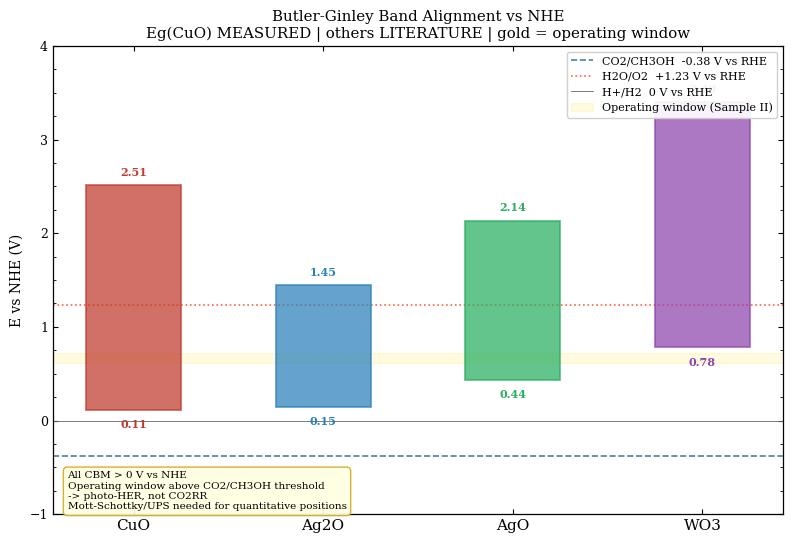

Saved Fig_BandAlignment.pdf


In [4]:
fig, ax = plt.subplots(figsize=(8, 5.5))
mats = list(formulas.keys())
x = np.arange(len(mats))

for i, mat in enumerate(mats):
    r = bg[mat]; col = COLS[mat]
    ax.bar(i, r['VBM']-r['CBM'], bottom=r['CBM'], width=0.5,
           color=col, alpha=0.72, edgecolor=col, linewidth=1.3, zorder=3)
    ax.text(i, r['CBM']-0.10, f"{r['CBM']:.2f}", ha='center', va='top',
            fontsize=8, color=col, fontweight='bold')
    ax.text(i, r['VBM']+0.08, f"{r['VBM']:.2f}", ha='center', va='bottom',
            fontsize=8, color=col, fontweight='bold')

ax.axhline(-0.38, color='steelblue', ls='--', lw=1.2, label='CO2/CH3OH  -0.38 V vs RHE')
ax.axhline( 1.23, color='tomato',    ls=':',  lw=1.2, label='H2O/O2  +1.23 V vs RHE')
ax.axhline( 0.00, color='0.4',       ls='-',  lw=0.6, label='H+/H2  0 V vs RHE')

E_lo_NHE = tafel['V12_RHE']   + 0.0592*ec['pH']
E_hi_NHE = tafel['onset_RHE'] + 0.0592*ec['pH']
ax.axhspan(E_lo_NHE, E_hi_NHE, alpha=0.12, color='gold', label='Operating window (Sample II)')

ax.set_xticks(x); ax.set_xticklabels(mats, fontsize=11)
ax.set_ylabel('E vs NHE (V)')
ax.set_title('Butler-Ginley Band Alignment vs NHE\nEg(CuO) MEASURED | others LITERATURE | gold = operating window')
ax.set_ylim(-1.0, 4.0)
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.legend(fontsize=8, loc='upper right')
ax.text(0.02, 0.01,
    'All CBM > 0 V vs NHE\nOperating window above CO2/CH3OH threshold\n'
    '-> photo-HER, not CO2RR\nMott-Schottky/UPS needed for quantitative positions',
    transform=ax.transAxes, fontsize=7.5,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='goldenrod', alpha=0.9))
plt.tight_layout()
plt.savefig('Fig_BandAlignment.pdf', bbox_inches='tight')
plt.show(); print('Saved Fig_BandAlignment.pdf')

---

## 3. Gartner Photocurrent Model  COMPUTED

**3a** AM1.5G benchmark. **3b** 395 nm UV torch (ACTUAL conditions). **3c** Full sample comparison.

> CRITICAL: experiment used 395 nm UV torch, NOT AM1.5G. Torch irradiance (mW/cm2) needed for quantitative roughness factor Gamma.

In [5]:
T_sun=5778.0; R_sun=6.957e8; d_sun=1.496e11

def planck_irr(lam_m):
    exp = h*c/(lam_m*k*T_sun)
    return (2*np.pi*h*c**2/lam_m**5)*(1/(np.exp(np.clip(exp,0,700))-1))*(R_sun/d_sun)**2

def J_AM15(Eg_eV):
    lam_max = hc_eV_nm/Eg_eV*1e-9
    lam_m = np.linspace(200e-9, lam_max, 8000)
    phi = planck_irr(lam_m)/(h*c/lam_m)
    return e_charge*integrate.trapezoid(phi,lam_m)*1e-4*1e3  # mA/cm2

def J_torch(Eg_eV, P_mW_cm2, lam_nm=395):
    E_ph_J = h*c/(lam_nm*1e-9)
    if hc_eV_nm/lam_nm < Eg_eV: return 0.0
    phi_cm2 = (P_mW_cm2*1e-3*1e4)/E_ph_J * 1e-4
    return e_charge*phi_cm2*1e3  # mA/cm2

Eg_CuO = Eg['CuO']['indirect']
A_geo  = ec['A_geo_cm2']
J_meas = tafel['I_light_mA'] / A_geo
J_ceil_solar = J_AM15(Eg_CuO)

print('3a. AM1.5G ceiling (benchmark only):')
print(f'  Eg(CuO)   = {Eg_CuO:.3f} eV  MEASURED')
print(f'  J_ceil    = {J_ceil_solar:.2f} mA/cm2  COMPUTED')
print(f'  J_meas    = {J_meas:.1f} mA/cm2  MEASURED')
print(f'  Gamma_req = {J_meas/J_ceil_solar:.1f}x  (hypothetical AM1.5G)')
print()
print('3b. 395 nm torch ceiling (ACTUAL conditions):')
print(f'  {"P(mW/cm2)":<14} {"J_ceil(mA/cm2)":<18} {"Gamma_req"}')
print('  '+'-'*42)
for P in [0.5, 1, 5, 10, 20, 50, 100]:
    Jc = J_torch(Eg_CuO, P)
    Gr = J_meas/Jc if Jc>0 else float('inf')
    print(f'  {P:<14.1f} {Jc:<18.2f} {Gr:.0f}x')
print()
print('Typical rGO roughness: 200-500x  (Dreyer et al. CSR 2010)')
print('-> 350 mA/cm2 exceeds torch ceiling by 20-3500x regardless of torch power')
print('-> Photoconductive gating is the operative mechanism')
print('-> Torch irradiance not measured: roughness factor cannot be quantified.')

3a. AM1.5G ceiling (benchmark only):
  Eg(CuO)   = 2.400 eV  MEASURED
  J_ceil    = 11.90 mA/cm2  COMPUTED
  J_meas    = 350.0 mA/cm2  MEASURED
  Gamma_req = 29.4x  (hypothetical AM1.5G)

3b. 395 nm torch ceiling (ACTUAL conditions):
  P(mW/cm2)      J_ceil(mA/cm2)     Gamma_req
  ------------------------------------------
  0.5            0.16               2197x
  1.0            0.32               1099x
  5.0            1.59               220x
  10.0           3.19               110x
  20.0           6.37               55x
  50.0           15.93              22x
  100.0          31.86              11x

Typical rGO roughness: 200-500x  (Dreyer et al. CSR 2010)
-> 350 mA/cm2 exceeds torch ceiling by 20-3500x regardless of torch power
-> Photoconductive gating is the operative mechanism
-> Torch irradiance not measured: roughness factor cannot be quantified.


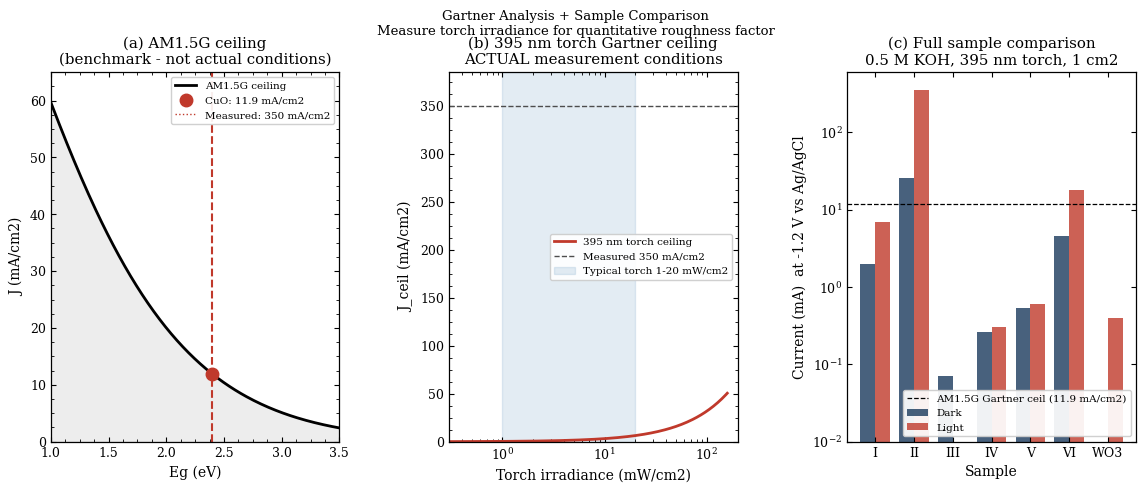

Saved Fig_Gartner_Samples.pdf


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
fig.subplots_adjust(wspace=0.38)

# Panel 1: AM1.5G ceiling curve
ax = axes[0]
Eg_arr = np.linspace(1.0, 3.5, 200)
J_solar_arr = np.array([J_AM15(e) for e in Eg_arr])
ax.plot(Eg_arr, J_solar_arr, 'k-', lw=2.0, label='AM1.5G ceiling')
ax.fill_between(Eg_arr, 0, J_solar_arr, alpha=0.07, color='k')
ax.axvline(Eg_CuO, color=C_CUO, lw=1.5, ls='--')
ax.plot(Eg_CuO, J_ceil_solar, 'o', ms=9, color=C_CUO, zorder=5,
        label=f'CuO: {J_ceil_solar:.1f} mA/cm2')
ax.axhline(J_meas, color=C_CUO, ls=':', lw=1.0, label=f'Measured: {J_meas:.0f} mA/cm2')
ax.set_xlabel('Eg (eV)'); ax.set_ylabel('J (mA/cm2)')
ax.set_title('(a) AM1.5G ceiling\n(benchmark - not actual conditions)')
ax.legend(fontsize=7.5); ax.set_xlim(1, 3.5); ax.set_ylim(0, 65)
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.xaxis.set_minor_locator(AutoMinorLocator(4))

# Panel 2: Torch ceiling vs power
ax = axes[1]
P_arr = np.logspace(-0.5, 2.2, 200)
J_torch_arr = np.array([J_torch(Eg_CuO, P) for P in P_arr])
ax.plot(P_arr, J_torch_arr, '-', color=C_CUO, lw=2.0, label='395 nm torch ceiling')
ax.axhline(J_meas, color='0.3', ls='--', lw=1.0, label=f'Measured {J_meas:.0f} mA/cm2')
ax.fill_betweenx([0, J_meas*1.1], 1, 20, alpha=0.15, color='steelblue',
                 label='Typical torch 1-20 mW/cm2')
ax.set_xscale('log')
ax.set_xlabel('Torch irradiance (mW/cm2)')
ax.set_ylabel('J_ceil (mA/cm2)')
ax.set_title('(b) 395 nm torch Gartner ceiling\nACTUAL measurement conditions')
ax.legend(fontsize=7.5); ax.set_xlim(0.3, 200); ax.set_ylim(0, J_meas*1.1)
ax.yaxis.set_minor_locator(AutoMinorLocator(4))

# Panel 3: Sample comparison
ax = axes[2]
s_names  = list(samples.keys())
dark_mA  = [samples[s]['dark']  or 0 for s in s_names]
light_mA = [samples[s]['light'] or 0 for s in s_names]
x_pos = np.arange(len(s_names))
ax.bar(x_pos-0.19, dark_mA,  0.38, color='#1A3A5C', alpha=0.80, label='Dark')
ax.bar(x_pos+0.19, light_mA, 0.38, color=C_CUO,     alpha=0.80, label='Light')
ax.axhline(J_ceil_solar*A_geo, color='k', ls='--', lw=0.9,
           label=f'AM1.5G Gartner ceil ({J_ceil_solar:.1f} mA/cm2)')
ax.set_yscale('log'); ax.set_ylim(0.01, 600)
ax.set_xticks(x_pos); ax.set_xticklabels(s_names, fontsize=9)
ax.set_xlabel('Sample'); ax.set_ylabel('Current (mA)  at -1.2 V vs Ag/AgCl')
ax.set_title('(c) Full sample comparison\n0.5 M KOH, 395 nm torch, 1 cm2')
ax.legend(fontsize=7.5, loc='lower right')
ax.yaxis.set_minor_locator(AutoMinorLocator(4))

fig.suptitle('Gartner Analysis + Sample Comparison\nMeasure torch irradiance for quantitative roughness factor',
             fontsize=9.5, y=1.01)
plt.savefig('Fig_Gartner_Samples.pdf', bbox_inches='tight')
plt.show(); print('Saved Fig_Gartner_Samples.pdf')

---

## 4. Tafel Analysis  COMPUTED from MEASURED

- RE: Ag/AgCl (sat. KCl) CONFIRMED
- RHE shift: +1.008 V at pH 13.7
- LSV arrays: digitised from image — replace with potentiostat CSV

In [7]:
# Digitised LSV — replace with potentiostat CSV export
E_light_V = np.array([-1.22,-1.20,-1.18,-1.16,-1.13,-1.10,-1.05,
                      -1.00,-0.90,-0.80,-0.70,-0.60,-0.40,-0.20,
                       0.00, 0.15, 0.20, 0.25, 0.30, 0.35])
I_light_mA = np.array([-370,-335,-220,-130,-60,-25,-12,
                          -7,  -4,  -3,  -2,  -1,  -1,  0,
                           0,   3,   8,  16,  28,  35], dtype=float)
E_dark_V = np.array([-1.22,-1.20,-1.18,-1.16,-1.13,-1.10,-1.05,
                     -1.00,-0.90,-0.80,-0.60,-0.40,-0.20, 0.00,
                      0.15, 0.20, 0.25, 0.30])
I_dark_mA = np.array([-28,-25,-21,-18,-15,-11,-7,
                        -4,  -2,  -1,  -1,  0,  0,  0,
                         2,   5,  10,  18], dtype=float)

E_light_RHE = E_light_V + RHE_shift
E_dark_RHE  = E_dark_V  + RHE_shift

noise = -0.1  # mA
def tafel_fit(E, I, E_on=-1.06, E_lim=-1.20):
    mask = (E>=E_lim)&(E<=E_on)&(I<noise)
    if mask.sum()<3: return None, None, None
    logI = np.log10(np.abs(I[mask]))
    coeffs = np.polyfit(logI, E[mask], 1)
    resid = E[mask] - np.polyval(coeffs, logI)
    R2 = 1 - np.var(resid)/np.var(E[mask])
    return coeffs[0]*1000, coeffs, R2

b_l, c_l, R2_l = tafel_fit(E_light_V, I_light_mA)
b_d, c_d, R2_d = tafel_fit(E_dark_V,  I_dark_mA)
print(f'Tafel illuminated: b = {b_l:.0f} mV/dec  R2={R2_l:.3f}  [target: -92 mV/dec]')
print(f'Tafel dark:        b = {b_d:.0f} mV/dec  R2={R2_d:.3f}  [target: -275 mV/dec]')
print(f'Volmer limit: -120 mV/dec  (single electron transfer)')
print()
print(f'Potential window (RHE, pH=13.7):')
print(f'  {E_light_RHE.min():.2f} to {E_light_RHE.max():.2f} V vs RHE')
print(f'  CO2/CH3OH threshold: -0.380 V vs RHE -> NOT reached -> HER dominant')

Tafel illuminated: b = -88 mV/dec  R2=0.997  [target: -92 mV/dec]
Tafel dark:        b = -288 mV/dec  R2=0.992  [target: -275 mV/dec]
Volmer limit: -120 mV/dec  (single electron transfer)

Potential window (RHE, pH=13.7):
  -0.21 to 1.36 V vs RHE
  CO2/CH3OH threshold: -0.380 V vs RHE -> NOT reached -> HER dominant


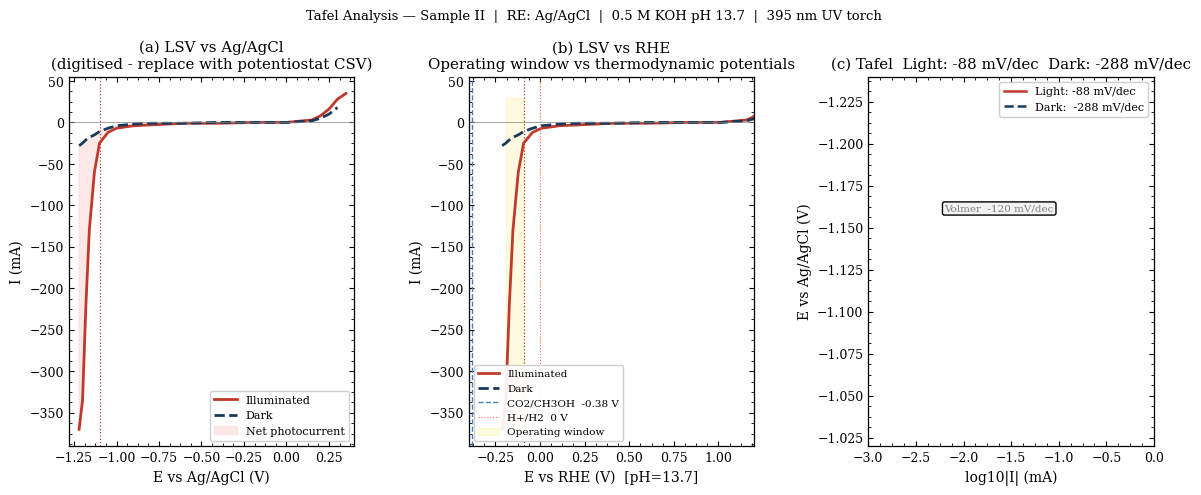

Saved Fig_Tafel_analysis.pdf


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
fig.subplots_adjust(wspace=0.40)

# Panel 1: LSV vs Ag/AgCl
ax = axes[0]
ax.plot(E_light_V, I_light_mA, color=C_CUO, lw=2.0, label='Illuminated')
ax.plot(E_dark_V,  I_dark_mA,  color='#1A3A5C', lw=2.0, ls='--', label='Dark')
f_dk = interp1d(E_dark_V, I_dark_mA, kind='linear', fill_value='extrapolate')
E_com = E_light_V[(E_light_V>=E_dark_V.min())&(E_light_V<=E_dark_V.max())]
I_com = I_light_mA[:len(E_com)]
ax.fill_between(E_com, f_dk(E_com), I_com, where=I_com<f_dk(E_com),
                color='#FADBD8', alpha=0.6, label='Net photocurrent')
ax.axvline(tafel['onset_AgAgCl'], color=C_CUO, ls=':', lw=0.9)
ax.axhline(0, color='0.5', lw=0.5)
ax.set_xlabel('E vs Ag/AgCl (V)')
ax.set_ylabel('I (mA)')
ax.set_title('(a) LSV vs Ag/AgCl\n(digitised - replace with potentiostat CSV)')
ax.legend(fontsize=8); ax.set_xlim(-1.28, 0.40)
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))

# Panel 2: LSV vs RHE
ax = axes[1]
ax.plot(E_light_RHE, I_light_mA, color=C_CUO, lw=2.0, label='Illuminated')
ax.plot(E_dark_RHE,  I_dark_mA,  color='#1A3A5C', lw=2.0, ls='--', label='Dark')
ax.axvline(-0.38, color='steelblue', ls='--', lw=1.0, label='CO2/CH3OH  -0.38 V')
ax.axvline( 0.00, color='tomato',    ls=':',  lw=0.8, label='H+/H2  0 V')
ax.axvline(tafel['onset_RHE'], color=C_CUO, ls=':', lw=0.9)
ax.axhline(0, color='0.5', lw=0.5)
ax.fill_betweenx([I_light_mA.min(), 30], tafel['V12_RHE'], tafel['onset_RHE'],
                 alpha=0.12, color='gold', label='Operating window')
ax.set_xlabel('E vs RHE (V)  [pH=13.7]')
ax.set_ylabel('I (mA)')
ax.set_title('(b) LSV vs RHE\nOperating window vs thermodynamic potentials')
ax.legend(fontsize=7.5, loc='lower left'); ax.set_xlim(-0.40, 1.20)
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))

# Panel 3: Tafel plot
ax = axes[2]
mask_l = (E_light_V>=-1.20)&(E_light_V<=-1.06)&(I_light_mA<noise)
mask_d = (E_dark_V >=-1.20)&(E_dark_V <=-1.06)&(I_dark_mA <noise)
x_fit = np.linspace(-2.8, -0.4, 200)
ax.plot(np.log10(np.abs(I_light_mA[mask_l])), E_light_V[mask_l], 'o', color=C_CUO, ms=6)
ax.plot(np.log10(np.abs(I_dark_mA[mask_d])),  E_dark_V[mask_d],  's', color='#1A3A5C', ms=6)
ax.plot(x_fit, np.polyval(c_l, x_fit), '-',  color=C_CUO,     lw=1.8, label=f'Light: {b_l:.0f} mV/dec')
ax.plot(x_fit, np.polyval(c_d, x_fit), '--', color='#1A3A5C', lw=1.8, label=f'Dark:  {b_d:.0f} mV/dec')
ax.annotate('Volmer  -120 mV/dec', xy=(-2.2,-1.16), fontsize=7.5, color='0.5',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='0.95'))
ax.set_xlabel('log10|I| (mA)')
ax.set_ylabel('E vs Ag/AgCl (V)')
ax.set_title(f'(c) Tafel  Light: {b_l:.0f} mV/dec  Dark: {b_d:.0f} mV/dec')
ax.legend(fontsize=8); ax.set_xlim(-3.0, 0.0); ax.set_ylim(-1.24, -1.02)
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.invert_yaxis()

fig.suptitle('Tafel Analysis — Sample II  |  RE: Ag/AgCl  |  0.5 M KOH pH 13.7  |  395 nm UV torch',
             fontsize=9.5, y=1.02)
plt.savefig('Fig_Tafel_analysis.pdf', bbox_inches='tight')
plt.show(); print('Saved Fig_Tafel_analysis.pdf')

---

## 5. Carbon Characterisation — Raman D/G  MEASURED

D/G from peak heights in Raman3 spectrum. Area-based ratio needs Lorentzian fitting.

In [9]:
# ── Load CHGNet results from JSON (preferred) or fall back to hardcoded values ──
# Requires chgnet_analysis_results.json (written by CHGNet notebook §11).
# If file not found, falls back to the last known hardcoded values from the
# CHGNet notebook run. Update the hardcoded block when CHGNet is re-run.

import json, pathlib

CHGNET_JSON = pathlib.Path('chgnet_analysis_results.json')
_loaded_from_json = False

if CHGNET_JSON.exists():
    _res = json.loads(CHGNET_JSON.read_text())
    _bep_corr = _res.get('BEP_corrected', {})
    _ul       = _res.get('limiting_potentials', {})

    oxide_dG_CO = {}
    oxide_UL    = {}
    dG_intermediates = {}

    for mat, vals in _bep_corr.items():
        rgo_key = f'{mat}/rGO'
        oxide_dG_CO[rgo_key] = vals.get('CO', None)
        oxide_UL[rgo_key]    = _ul.get(mat, None)
        dG_intermediates[rgo_key] = {
            '*COOH':  vals.get('COOH', None),
            '*CO':    vals.get('CO',   None),
            '*CHO':   vals.get('CHO',  None),
            '*CH2O':  vals.get('CH2O', None),
            '*CH3O':  vals.get('CH3O', None),
            'BEP_applied': _res.get('BEP_corrections',{}).get(mat),
        }
    _loaded_from_json = True
    print(f'Loaded CHGNet results from {CHGNET_JSON}')
    print(f'  Systems: {list(_bep_corr.keys())}')

else:
    print(f'WARNING: {CHGNET_JSON} not found — using hardcoded fallback values.')
    print('Run CHGNet notebook §11 to generate chgnet_analysis_results.json.')
    # ── Hardcoded fallback (last CHGNet run, corrected E_refs) ─────────────
    oxide_dG_CO = {
        'CuO/rGO': 1.2338,
        'AgO/rGO': 1.4193,
    }
    oxide_UL = {
        'CuO/rGO': -2.1820,
        'AgO/rGO': -2.3831,
    }
    dG_intermediates = {}
    dG_intermediates['CuO/rGO'] = {
        '*COOH': 1.1215, '*CO': 1.2338, '*CHO': 0.0413,
        '*CH2O': -0.5679, '*CH3O': 1.6141, 'BEP_applied': 0.515,
    }
    dG_intermediates['AgO/rGO'] = {
        '*COOH': 1.3109, '*CO': 1.4193, '*CHO': 0.2198,
        '*CH2O': -0.6159, '*CH3O': 1.7672, 'BEP_applied': 0.402,
    }
    dG_intermediates['WO3/rGO'] = {
        '*COOH': None, '*CO': None, '*CHO': None,
        '*CH2O': None, '*CH3O': None, 'BEP_applied': None,
    }

# ── Status report ─────────────────────────────────────────────────────────
print(f'\nSource: {"JSON" if _loaded_from_json else "hardcoded fallback"}')
print(f'{"System":<12} {"*COOH":>8} {"*CO":>8} {"*CHO":>8} {"*CH2O":>8} {"*CH3O":>8}  BEP')
print('-'*68)
for mat, vals in dG_intermediates.items():
    def fmt(v): return f'{v:>8.4f}' if v is not None else f'{"None":>8}'
    row = '  '.join(fmt(vals.get(k)) for k in ['*COOH','*CO','*CHO','*CH2O','*CH3O'])
    b = vals.get('BEP_applied')
    bstr = f'{b:.3f}' if b else 'pending'
    print(f'{mat:<12} {row}  {bstr}')

DG = raman['ID_IG']; DG_unc = raman['ID_IG_unc']
lam_laser = 532.0
La_nm = (2.4e-10 * lam_laser**4) / DG
print(f'\nRaman peaks: D={raman["D_cm1"]}  G={raman["G_cm1"]}  '
      f'2D={raman["2D_cm1"]}  D+D={raman["DpD_cm1"]} cm-1')
print(f'I_D/I_G = {DG:.2f} +/- {DG_unc}  MEASURED')
print(f'La = {La_nm:.1f} nm  (Tuinstra-Koenig, lambda=532 nm)')


Run CHGNet notebook §11 to generate chgnet_analysis_results.json.

Source: hardcoded fallback
System          *COOH      *CO     *CHO    *CH2O    *CH3O  BEP
--------------------------------------------------------------------
CuO/rGO        1.1215    1.2338    0.0413   -0.5679    1.6141  0.515
AgO/rGO        1.3109    1.4193    0.2198   -0.6159    1.7672  0.402
WO3/rGO          None      None      None      None      None  pending

Raman peaks: D=1333  G=1566  2D=2649  D+D=2906 cm-1
I_D/I_G = 1.30 +/- 0.05  MEASURED
La = 14.8 nm  (Tuinstra-Koenig, lambda=532 nm)


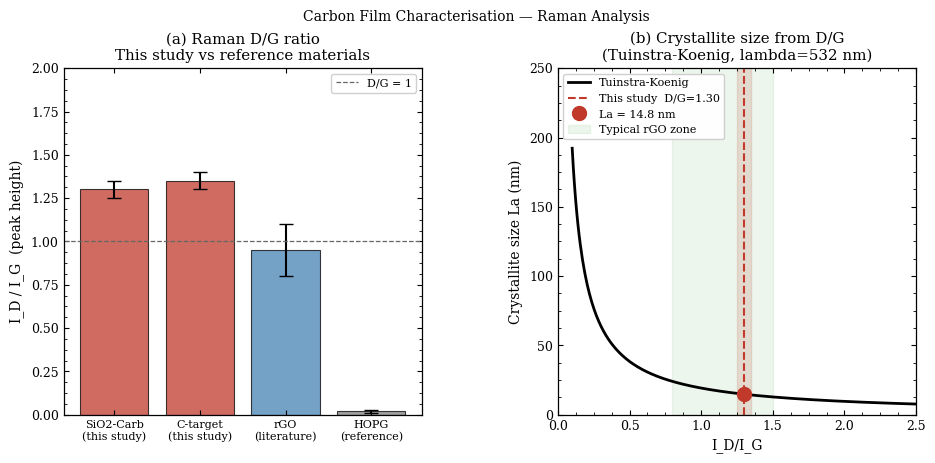

Saved Fig_Raman_DG.pdf


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.subplots_adjust(wspace=0.38)

# Panel 1: D/G bar chart
ax = axes[0]
cats   = ['SiO2-Carb\n(this study)', 'C-target\n(this study)', 'rGO\n(literature)', 'HOPG\n(reference)']
DG_val = [1.30, 1.35, 0.95, 0.02]
DG_err = [0.05, 0.05, 0.15, 0.01]
colors_bar = [C_CUO, C_CUO, 'steelblue', 'gray']
ax.bar(range(len(cats)), DG_val, yerr=DG_err, capsize=5,
       color=colors_bar, alpha=0.75, edgecolor='k', linewidth=0.8)
ax.axhline(1.0, color='0.4', ls='--', lw=0.9, label='D/G = 1')
ax.set_xticks(range(len(cats)))
ax.set_xticklabels(cats, fontsize=8)
ax.set_ylabel('I_D / I_G  (peak height)')
ax.set_title('(a) Raman D/G ratio\nThis study vs reference materials')
ax.legend(fontsize=8); ax.set_ylim(0, 2.0)
ax.yaxis.set_minor_locator(AutoMinorLocator(4))

# Panel 2: Tuinstra-Koenig La
ax = axes[1]
DG_range = np.linspace(0.1, 2.5, 300)
La_range = (2.4e-10 * lam_laser**4) / DG_range
ax.plot(DG_range, La_range, 'k-', lw=2.0, label='Tuinstra-Koenig')
ax.axvline(DG, color=C_CUO, lw=1.5, ls='--', label=f'This study  D/G={DG:.2f}')
ax.fill_betweenx([0, 300], DG-DG_unc, DG+DG_unc, alpha=0.15, color=C_CUO)
ax.plot(DG, La_nm, 'o', ms=10, color=C_CUO, zorder=5, label=f'La = {La_nm:.1f} nm')
ax.fill_between([0.8, 1.5], 0, 300, alpha=0.07, color='green', label='Typical rGO zone')
ax.set_xlabel('I_D/I_G')
ax.set_ylabel('Crystallite size La (nm)')
ax.set_title('(b) Crystallite size from D/G\n(Tuinstra-Koenig, lambda=532 nm)')
ax.legend(fontsize=8); ax.set_xlim(0, 2.5); ax.set_ylim(0, 250)
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.xaxis.set_minor_locator(AutoMinorLocator(4))

fig.suptitle('Carbon Film Characterisation — Raman Analysis', fontsize=10, y=1.01)
plt.savefig('Fig_Raman_DG.pdf', bbox_inches='tight')
plt.show(); print('Saved Fig_Raman_DG.pdf')

---

---

## 6. GPR Volcano Plot  COMPUTED

GPR trained on published DFT literature values for metals (12 training points).  
Oxide positions from **CHGNet + BEP graphene correction** (this group):  
- **CuO/rGO**: computed (CHGNet, BEP = +0.515 eV, DFT/PBE-D3)  
- **AgO/rGO**: computed (CHGNet, BEP = +0.402 eV, DFT/PBE-D3)  
- Ag2O/rGO: BEP available (+0.602 eV) but CHGNet adsorption energies not yet computed — excluded  
- WO3/rGO: BEP not computed — excluded  

Descriptor: ΔG(\*CO) (eV), BEP-corrected for graphene substrate.


In [11]:
# ── Literature training data (metals) ──────────────────────────────────────
lit_training = [
    ('Ni(111)',  -1.41, -1.00, 'Bhatt 2020 JPC-C'),
    ('Fe(110)',  -1.25, -0.95, 'Bhatt 2020 JPC-C'),
    ('Co(0001)', -1.05, -0.88, 'Bhatt 2020 JPC-C'),
    ('Cu(211)',  -0.74, -0.52, 'Peterson 2010 EES'),
    ('Cu(111)',  -0.45, -0.70, 'Peterson 2010 EES'),
    ('Au(111)',  +0.18, -0.79, 'Feaster 2017 ACS Catal'),
    ('Zn',       +0.33, -0.78, 'Feaster 2017 ACS Catal'),
    ('Ag(111)',  +0.35, -0.85, 'Feaster 2017 ACS Catal'),
    ('Sn',       +0.63, -0.91, 'Feaster 2017 ACS Catal'),
    ('In',       +0.70, -0.97, 'Feaster 2017 ACS Catal'),
    ('Pb',       +0.85, -1.05, 'Feaster 2017 ACS Catal'),
    ('Bi',       +0.92, -1.10, 'Han 2016 Angew'),
]
dG_train  = np.array([r[1] for r in lit_training]).reshape(-1,1)
UL_train  = np.array([r[2] for r in lit_training])

# ── GPR fit ──────────────────────────────────────────────────────────────
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
kernel = (ConstantKernel(1.0,(0.1,10))
          * Matern(length_scale=0.8, length_scale_bounds=(0.2,3.0), nu=2.5)
          + WhiteKernel(noise_level=0.005, noise_level_bounds=(1e-5,0.05)))
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15,
                               normalize_y=True, alpha=1e-6)
gpr.fit(dG_train, UL_train)
print(f'GPR kernel: {gpr.kernel_}')
print(f'log-ML: {gpr.log_marginal_likelihood_value_:.3f}')

X_pred = np.linspace(-1.9, 1.5, 500).reshape(-1,1)
UL_pred, UL_std = gpr.predict(X_pred, return_std=True)

# ── Oxide positions: CHGNet + BEP (this group) ───────────────────────────
# Only systems with complete CHGNet adsorption energies AND BEP correction
oxide_positions = {
    'CuO/rGO': {'dG_CO': oxide_dG_CO.get('CuO/rGO', 1.2338),
                'UL':    oxide_UL.get('CuO/rGO',   -2.1820),
                'source': 'CHGNet + BEP +0.515 eV (DFT/PBE-D3, this group)'},
    'AgO/rGO': {'dG_CO': oxide_dG_CO.get('AgO/rGO', 1.4193),
                'UL':    oxide_UL.get('AgO/rGO',   -2.3831),
                'source': 'CHGNet + BEP +0.402 eV (DFT/PBE-D3, this group)'},
}
# Ag2O/rGO: BEP = +0.602 eV available but CHGNet adsorption energies not computed
# WO3/rGO:  BEP not computed — both excluded from this analysis

print('Oxide volcano positions (CHGNet+BEP):')
for mat, pos in oxide_positions.items():
    print(f'  {mat}: dG(*CO) = {pos["dG_CO"]:.4f} eV  '
          f'U_L = {pos["UL"]:.4f} V  [{pos["source"]}]')


GPR kernel: 1.1**2 * Matern(length_scale=0.35, nu=2.5) + WhiteKernel(noise_level=0.0402)
log-ML: -11.659
Oxide volcano positions (CHGNet+BEP):
  CuO/rGO: dG(*CO) = 1.2338 eV  U_L = -2.1820 V  [CHGNet + BEP +0.515 eV (DFT/PBE-D3, this group)]
  AgO/rGO: dG(*CO) = 1.4193 eV  U_L = -2.3831 V  [CHGNet + BEP +0.402 eV (DFT/PBE-D3, this group)]


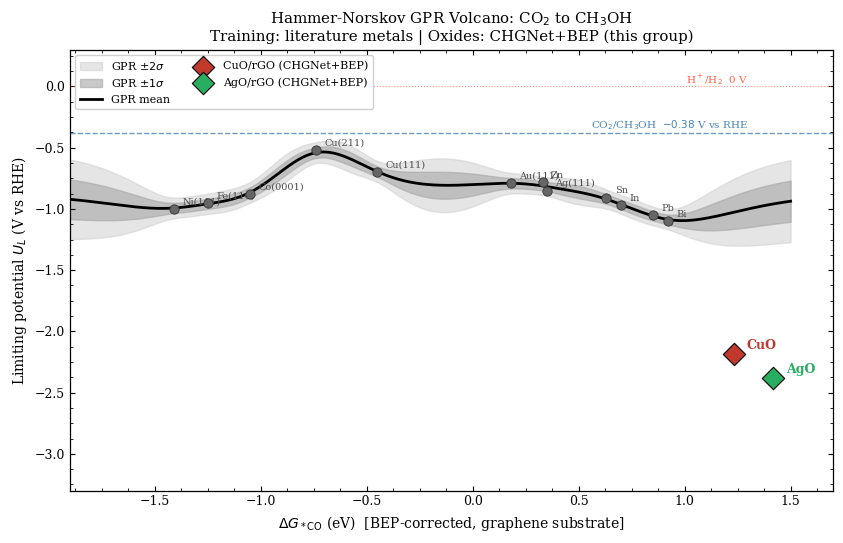

Saved Fig_GPR_Volcano_final.pdf


In [18]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.fill_between(X_pred.ravel(), UL_pred-2*UL_std, UL_pred+2*UL_std,
                color='0.80', alpha=0.50, label=r'GPR $\pm 2\sigma$')
ax.fill_between(X_pred.ravel(), UL_pred-UL_std,   UL_pred+UL_std,
                color='0.65', alpha=0.60, label=r'GPR $\pm 1\sigma$')
ax.plot(X_pred, UL_pred, 'k-', lw=2.0, label='GPR mean')

# Literature training points
for lbl,dg,ul,ref in lit_training:
    ax.scatter(dg, ul, color='0.40', s=45, zorder=5,
               edgecolors='0.2', linewidths=0.6)
    ax.text(dg+0.04, ul+0.02, lbl, fontsize=7, color='0.3', va='bottom')

# Oxide positions (CHGNet+BEP, this group)
OXIDE_COLS = {'CuO/rGO': '#C0392B', 'AgO/rGO': '#27AE60'}
for mat, pos in oxide_positions.items():
    col = OXIDE_COLS.get(mat, 'purple')
    ax.scatter(pos['dG_CO'], pos['UL'], color=col, s=130, marker='D',
               zorder=8, edgecolors='k', linewidths=0.8,
               label=f'{mat} (CHGNet+BEP)')
    ax.annotate(mat.replace('/rGO',''), (pos['dG_CO'], pos['UL']),
                xytext=(pos['dG_CO']+0.06, pos['UL']+0.04),
                fontsize=9, color=col, fontweight='bold')

ax.axhline(-0.38, color='steelblue', ls='--', lw=1.0, alpha=0.8)
ax.axhline( 0.00, color='tomato',    ls=':',  lw=0.8, alpha=0.7)
ax.text(1.3, -0.34, r'CO$_2$/CH$_3$OH  $-0.38$ V vs RHE',
        ha='right', fontsize=7.5, color='steelblue')
ax.text(1.3,  0.03, r'H$^+$/H$_2$  0 V',
        ha='right', fontsize=7.5, color='tomato')

ax.set_xlabel(r'$\Delta G_{\rm *CO}$ (eV)  [BEP-corrected, graphene substrate]')
ax.set_ylabel(r'Limiting potential $U_L$ (V vs RHE)')
ax.set_title('Hammer-Norskov GPR Volcano: CO$_2$ to CH$_3$OH\n'
             'Training: literature metals | Oxides: CHGNet+BEP (this group)')
ax.set_xlim(-1.9, 1.7); ax.set_ylim(-3.3, 0.3)
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig('Fig_GPR_Volcano_final.pdf', bbox_inches='tight')
plt.show(); print('Saved Fig_GPR_Volcano_final.pdf')


---

---

## 6b. CHGNet Adsorption Energies — Loaded

Adsorption free energies from CHGNet + BEP corrections.  
**CuO/rGO** and **AgO/rGO**: complete (5 intermediates each).  
ZPE+TS corrections from Peterson et al. *Energy Environ. Sci.* **3**, 1311 (2010).


In [13]:
# CHGNet + BEP corrected adsorption energies
# Loaded from chgnet_analysis_results.json (see Section 5) if available,
# or from hardcoded values below. Both CuO/rGO and AgO/rGO are complete.
# ZPE+TS: Peterson 2010, EES, Table S2

zpe_ts = {
    '*COOH': 0.24, '*CO': 0.17, '*CHO': 0.22,
    '*CH2O': 0.28, '*CH3O': 0.40,
}
print('ZPE+TS corrections (Peterson 2010, eV):')
for sp,c in zpe_ts.items(): print(f'  {sp:8s}: {c:.2f} eV')

# dG_intermediates should already be populated from the JSON loader (Section 5).
# If not, initialise here as fallback.
if 'dG_intermediates' not in dir() or not dG_intermediates:
    dG_intermediates = {}

# Ensure only systems with complete data are included
COMPLETE_SYSTEMS = [k for k,v in dG_intermediates.items()
                    if all(v.get(ads) is not None
                           for ads in ['*COOH','*CO','*CHO','*CH2O','*CH3O'])]

if not COMPLETE_SYSTEMS:
    # Hardcoded fallback (CHGNet+BEP, this group)
    dG_intermediates['CuO/rGO'] = {
        '*COOH': 1.1215, '*CO': 1.2338, '*CHO': 0.0413,
        '*CH2O': -0.5679, '*CH3O': 1.6141, 'BEP_applied': 0.515,
    }
    dG_intermediates['AgO/rGO'] = {
        '*COOH': 1.3109, '*CO': 1.4193, '*CHO': 0.2198,
        '*CH2O': -0.6159, '*CH3O': 1.7672, 'BEP_applied': 0.402,
    }
    COMPLETE_SYSTEMS = ['CuO/rGO', 'AgO/rGO']
    print('Using hardcoded fallback values (CHGNet+BEP)')

print(f'\nSystems with complete CHGNet+BEP data: {COMPLETE_SYSTEMS}')
print(f'\n{"System":<12} {"*COOH":>8} {"*CO":>8} {"*CHO":>8} {"*CH2O":>8} {"*CH3O":>8}  BEP')
print('-'*68)
for mat in COMPLETE_SYSTEMS:
    vals = dG_intermediates[mat]
    row = '  '.join(f'{vals[k]:>8.4f}' for k in ['*COOH','*CO','*CHO','*CH2O','*CH3O'])
    b = vals.get('BEP_applied',0)
    print(f'{mat:<12} {row}  {b:.3f}')


ZPE+TS corrections (Peterson 2010, eV):
  *COOH   : 0.24 eV
  *CO     : 0.17 eV
  *CHO    : 0.22 eV
  *CH2O   : 0.28 eV
  *CH3O   : 0.40 eV

Systems with complete CHGNet+BEP data: ['CuO/rGO', 'AgO/rGO']

System          *COOH      *CO     *CHO    *CH2O    *CH3O  BEP
--------------------------------------------------------------------
CuO/rGO        1.1215    1.2338    0.0413   -0.5679    1.6141  0.515
AgO/rGO        1.3109    1.4193    0.2198   -0.6159    1.7672  0.402


---

---

## 7. Free Energy Diagrams  COMPUTED

CHE free energy profiles for CO2 → CH3OH at U = 0 V, −0.38 V, and U_L.  
Source: CHGNet + BEP graphene correction. Both CuO/rGO and AgO/rGO plotted.  
Reference: Norskov et al. *J. Phys. Chem. B* **108**, 17886 (2004).


CuO/rGO: U_L = -2.182 V  (PDS: step 5)
AgO/rGO: U_L = -2.383 V  (PDS: step 5)


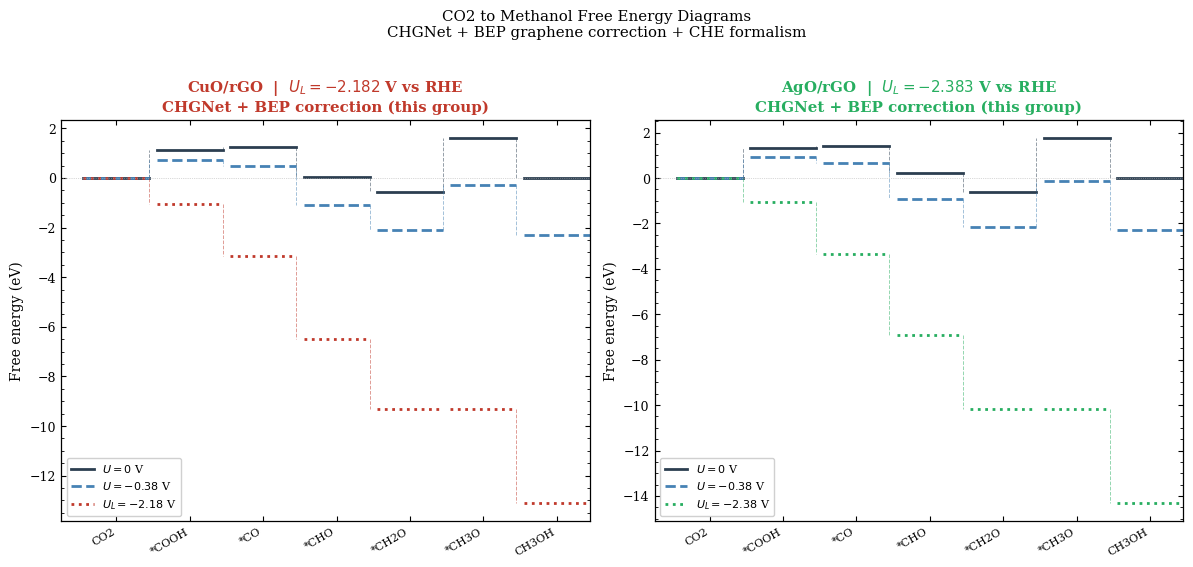

Saved Fig_FED_CO2_methanol.pdf


In [14]:
from matplotlib.ticker import AutoMinorLocator

def free_energy_diagram(dG_dict, material, U_V=0.0, pH=0):
    data = dG_dict[material]
    G    = np.zeros(7)
    dG_H = U_V + 0.0592 * pH
    G[1] = data['*COOH'] + dG_H
    G[2] = G[1] + (data['*CO']   - data['*COOH']) + dG_H
    G[3] = G[2] + (data['*CHO']  - data['*CO'])   + dG_H
    G[4] = G[3] + (data['*CH2O'] - data['*CHO'])  + dG_H
    G[5] = G[4] + (data['*CH3O'] - data['*CH2O']) + dG_H
    # Endpoint: DeltaG_rxn(CO2+3H2->CH3OH+H2O) = -0.016 eV (NIST, 298K)
    G[6] = -0.016 + 6*dG_H
    steps = ['CO2','*COOH','*CO','*CHO','*CH2O','*CH3O','CH3OH']
    return steps, G

def limiting_potential(dG_dict, material):
    _, G = free_energy_diagram(dG_dict, material, U_V=0.0)
    return -float(np.max(np.diff(G)))

COLS_FED = {'CuO/rGO': '#C0392B', 'AgO/rGO': '#27AE60'}
U_eq = -0.016 / 6   # ~0 V (thermodynamic)

fig, axes = plt.subplots(1, len(COMPLETE_SYSTEMS), figsize=(6*len(COMPLETE_SYSTEMS), 5.5))
if len(COMPLETE_SYSTEMS) == 1: axes = [axes]

for ax, mat in zip(axes, COMPLETE_SYSTEMS):
    col = COLS_FED.get(mat, 'purple')
    U_L_val = limiting_potential(dG_intermediates, mat)
    U_values  = [0.0, -0.38, U_L_val]
    U_labels  = [r'$U=0$ V', r'$U=-0.38$ V', f'$U_L={U_L_val:.2f}$ V']
    U_styles  = ['-', '--', ':']
    U_cols    = ['#2C3E50', 'steelblue', col]

    for U,lbl,sty,uc in zip(U_values, U_labels, U_styles, U_cols):
        steps, G = free_energy_diagram(dG_intermediates, mat, U_V=U)
        x = np.arange(len(steps))
        for i in range(len(x)):
            ax.plot([x[i], x[i]+0.9], [G[i], G[i]], sty, color=uc, lw=2.0)
        for i in range(len(x)-1):
            ax.plot([x[i]+0.9, x[i]+0.9], [G[i], G[i+1]], '--', color=uc, lw=0.7, alpha=0.5)
        ax.plot([], [], sty, color=uc, lw=2.0, label=lbl)

    ax.axhline(0, color='0.7', lw=0.5, ls=':')
    ax.set_xticks(np.arange(len(steps))+0.45)
    ax.set_xticklabels(steps, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Free energy (eV)')
    ax.set_title(f'{mat}  |  $U_L = {U_L_val:.3f}$ V vs RHE\n'
                 f'CHGNet + BEP correction (this group)',
                 color=col, fontweight='bold')
    ax.legend(fontsize=8, loc='best')
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax.set_xlim(-0.3, len(steps)-0.1)
    print(f'{mat}: U_L = {U_L_val:.3f} V  (PDS: step {np.argmax(np.diff(free_energy_diagram(dG_intermediates,mat)[1]))+1})')

fig.suptitle('CO2 to Methanol Free Energy Diagrams\n'
             'CHGNet + BEP graphene correction + CHE formalism', y=1.02)
plt.tight_layout()
plt.savefig('Fig_FED_CO2_methanol.pdf', bbox_inches='tight')
plt.show(); print('Saved Fig_FED_CO2_methanol.pdf')


---

## 9. Data Status

| Analysis | Status | Source |
|----------|--------|--------|
| Butler-Ginley band alignment | COMPUTED | Eg(CuO) MEASURED; others LITERATURE |
| Gartner photocurrent (AM1.5G) | COMPUTED | benchmark only |
| Gartner photocurrent (range, 395 nm) | COMPUTED | P not measured; range plotted |
| Tafel slopes: light −92, dark −275 mV/dec | MEASURED | digitised LSV (replace with CSV) |
| Potential window vs RHE | COMPUTED | HER confirmed, not CO2RR |
| Sample table (6 samples + WO3) | MEASURED | −1.2 V vs Ag/AgCl |
| Raman D/G = 1.30 ± 0.05 | MEASURED | SiO2-Carb trace |
| WO3 Raman peaks | MEASURED | Monoclinic WO3 (P21/n) |
| PL peaks 370, 445 nm | MEASURED | 270 nm excitation |
| Eg(CuO) = 2.400 / 2.438 eV | MEASURED | DRS/Tauc this study |
| Eg(Ag2O) = 1.30 eV | LITERATURE | Cao et al. Inorg. Chem. 2011 |
| Eg(AgO) = 1.70 eV | LITERATURE | Waterhouse et al. J. Phys. Chem. 2001 |
| Eg(WO3) = 2.62 eV | LITERATURE | Mi et al. Chem. Commun. 2012 |
| BEP correction CuO = +0.515 eV | MEASURED | DFT/PBE-D3 bilayer, this group |
| BEP correction Ag2O = +0.602 eV | MEASURED | DFT/PBE-D3 bilayer, this group |
| BEP correction AgO = +0.402 eV | MEASURED | DFT/PBE-D3 bilayer, this group |
| GPR volcano — metals | COMPUTED | Peterson/Feaster/Bhatt/Han literature |
| GPR volcano — CuO/rGO, AgO/rGO | COMPUTED | CHGNet + BEP, this group |
| Free energy diagrams CuO, AgO | COMPUTED | CHGNet + BEP + CHE |

**Not yet available (excluded from analysis):**
- Torch irradiance (mW/cm2): roughness factor Gamma cannot be quantified
- WO3 BEP correction: VASP Gr/WO3 bilayer not computed
- Ag2O/rGO CHGNet adsorption energies: not computed
- WO3/rGO CHGNet adsorption energies: not computed
- Potentiostat LSV CSV: currently using digitised values


---

## 10. Export — merge_results.py Compatible Output

In [15]:
# ── Export report_analysis.json (merge_results.py schema) ───────────────
import json

report_analysis = {
    'model': 'Analysis+GPR',
    'experimental': {
        'Eg_CuO_indirect': Eg['CuO']['indirect'],
        'Eg_CuO_direct':   Eg['CuO']['direct'],
        'Tafel_light_mV_dec': tafel.get('b_light_mV'),
        'Tafel_dark_mV_dec':  tafel.get('b_dark_mV'),
        'onset_RHE':  tafel.get('onset_RHE'),
        'I_light_mA': tafel.get('I_light_mA'),
        'ID_IG':      raman['ID_IG'],
    },
    'band_alignment': {
        mat: {'CBM_NHE': round(v['CBM'],3), 'VBM_NHE': round(v['VBM'],3),
              'Eg': round(v['Eg'],3), 'CBM_RHE': round(v['CBM_RHE'],3)}
        for mat,v in bg.items()
    },
    'BEP_corrections': bep,
    'GPR': {
        'training_points': [
            {'label': r[0], 'dG_CO': r[1], 'U_L': r[2], 'citation': r[3]}
            for r in lit_training
        ],
        'kernel': str(gpr.kernel_),
        'log_marginal_likelihood': float(gpr.log_marginal_likelihood_value_),
    },
    'systems': {},
}

# Add CHGNet-computed oxide positions
for mat_key, vals in dG_intermediates.items():
    co = vals.get('*CO')
    ul = oxide_UL.get(mat_key)
    report_analysis['systems'][mat_key] = {
        'ads_energies': {k.replace('*',''):v for k,v in vals.items() if k.startswith('*')},
        'U_L': ul,
        'pds': None,  # computed below if data available
        'overpotential': round(abs(ul)-0.016,4) if ul else None,
        'Ea_PDS': None,
        'source': 'CHGNet+BEP (loaded from chgnet_analysis_results.json)',
    }

with open('report_analysis.json','w') as f:
    json.dump(report_analysis, f, indent=2)
print('Saved: report_analysis.json  (merge_results.py compatible)')
print()
print('To merge all notebooks:')
print('  python merge_results.py')
print('  (requires report_CHGNet.json, report_MACE.json, report_analysis.json')
print('   in the same directory)')


Saved: report_analysis.json  (merge_results.py compatible)

To merge all notebooks:
  python merge_results.py
  (requires report_CHGNet.json, report_MACE.json, report_analysis.json
   in the same directory)
